<a href="https://colab.research.google.com/github/mikysetiawan/FundamentalDeepL/blob/master/Tugas_1_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install & Import Lib

In [30]:
!pip install pipreqs
!pip install sastrawi
!pip install gensim

In [83]:
import pandas as pd  # Pandas untuk manipulasi dan analisis data
pd.options.mode.chained_assignment = None  # Menonaktifkan peringatan chaining

import numpy as np  # NumPy untuk komputasi numerik
seed = 0
np.random.seed(seed)  # Mengatur seed untuk reproduktibilitas
import matplotlib.pyplot as plt  # Matplotlib untuk visualisasi data
import seaborn as sns  # Seaborn untuk visualisasi data statistik, mengatur gaya visualisasi
from sklearn.metrics import accuracy_score

import datetime as dt  # Manipulasi data waktu dan tanggal
import re  # Modul untuk bekerja dengan ekspresi reguler
import string  # Berisi konstanta string, seperti tanda baca
from nltk.tokenize import word_tokenize  # Tokenisasi teks
from nltk.corpus import stopwords  # Daftar kata-kata berhenti dalam teks

import csv
import requests
from io import StringIO

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Menghapus kata-kata berhenti dalam bahasa Indonesia

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
from gensim.models import Word2Vec

from wordcloud import WordCloud  # Membuat visualisasi berbentuk awan kata (word cloud) dari teks

import nltk  # Import pustaka NLTK (Natural Language Toolkit).
nltk.download('punkt')  # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('punkt_tab')  # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('stopwords')  # Mengunduh dataset yang berisi daftar kata-kata berhenti (stopwords) dalam berbagai bahasa.

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Load data from csv and load to pandas

In [61]:
# Load data dari csv ulasan_aplikasi.csv
datas = pd.read_csv('ulasan_aplikasi.csv')

# Membuat DataFrame dari hasil scrapreview
app_reviews_df = pd.DataFrame(datas)

# Menghitung jumlah baris dan kolom dalam DataFrame
jumlah_ulasan, jumlah_kolom = app_reviews_df.shape

app_reviews_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,189993c1-d607-4d21-8758-3400c72ee7ce,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,banyak driver pada males jemput. rata² semua d...,1,5,5.56.2,2026-04-19 13:19:11,"Hai Kak Jihan, mohon maaf atas ketidaknyamanan...",2026-04-19 14:03:45,5.56.2
1,1b70120d-9109-4727-81ed-b4daa5aee58c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Game baru Bolak Balok banyak bug, peningkatan ...",3,2,5.57.2,2026-04-29 07:59:55,"Hai Kak Nanang, mohon maaf atas kendalanya. Pa...",2026-04-29 08:42:32,5.57.2
2,fa42d47a-8dc0-465d-bcdf-6efb76536caa,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Kenapa saya nggak bisa main bolak-balok lagi s...,1,2,5.57.2,2026-04-29 21:21:21,"Hai Kak Rivaldi, mohon maaf atas ketidaknyaman...",2026-04-29 21:34:03,5.57.2
3,3aea3e6c-6756-474d-aa21-469a15d3af89,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"gajelas ni makin ksini, di kasih taunya tingga...",3,5,5.55.2,2026-04-14 07:13:13,"Hai Kak Alscha, mohon maaf atas ketidaknyamana...",2026-04-14 08:40:57,5.55.2
4,09a3049c-e8dc-42a5-b627-4855e979a441,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tambah menurun ...biasa klu sdh dikenal pasti ...,1,4,5.57.2,2026-04-27 18:40:12,"Hai Kak Anik, mohon maaf atas ketidaknyamanann...",2026-03-17 21:19:12,5.57.2


In [62]:
# Menampilkan informasi tentang DataFrame app_reviews_df
app_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              30000 non-null  object
 1   userName              30000 non-null  object
 2   userImage             30000 non-null  object
 3   content               30000 non-null  object
 4   score                 30000 non-null  int64 
 5   thumbsUpCount         30000 non-null  int64 
 6   reviewCreatedVersion  24330 non-null  object
 7   at                    30000 non-null  object
 8   replyContent          14436 non-null  object
 9   repliedAt             14436 non-null  object
 10  appVersion            24330 non-null  object
dtypes: int64(2), object(9)
memory usage: 2.5+ MB


In [63]:
# Membuat DataFrame baru (clean_df) dengan menghapus baris yang memiliki nilai yang hilang (NaN) dari app_reviews_df
clean_df = app_reviews_df.dropna()

In [64]:
# Menghapus baris duplikat dari DataFrame clean_df
clean_df = clean_df.drop_duplicates()

# Menghitung jumlah baris dan kolom dalam DataFrame clean_df setelah menghapus duplikat
jumlah_ulasan_setelah_hapus_duplikat, jumlah_kolom_setelah_hapus_duplikat = clean_df.shape

clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11597 entries, 0 to 29997
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              11597 non-null  object
 1   userName              11597 non-null  object
 2   userImage             11597 non-null  object
 3   content               11597 non-null  object
 4   score                 11597 non-null  int64 
 5   thumbsUpCount         11597 non-null  int64 
 6   reviewCreatedVersion  11597 non-null  object
 7   at                    11597 non-null  object
 8   replyContent          11597 non-null  object
 9   repliedAt             11597 non-null  object
 10  appVersion            11597 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.1+ MB


**Preprocessing Text**

In [58]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka

    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text

def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text

def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text)
    return text

def filteringText(text): # Menghapus stopwords dalam teks
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

def stemmingText(text): # Mengurangi kata ke bentuk dasarnya yang menghilangkan imbuhan awalan dan akhiran atau ke akar kata
    # Membuat objek stemmer
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

    # Memecah teks menjadi daftar kata
    words = text.split()

    # Menerapkan stemming pada setiap kata dalam daftar
    stemmed_words = [stemmer.stem(word) for word in words]

    # Menggabungkan kata-kata yang telah distem
    stemmed_text = ' '.join(stemmed_words)

    return stemmed_text

def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

In [59]:
slangwords = {
    "@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar",
    "bgt": "banget", "maks": "maksimal", "min": "minimal", "teros": "terus", "krn": "karena",
    "yg": "yang", "gk": "tidak", "kalo": "kalau", "udah": "sudah", "aja": "saja", "tau": "tahu",
    "tp": "tapi", "rb": "ribu", "pake": "pakai", "tdk": "tidak", "pa": "apa", "app": "aplikasi",
    "gitu": "begitu", "gabisa": "tidak bisa", "klo": "kalau", "nggak": "tidak", "ngga": "tidak", "banget": "sangat",
    "udh": "sudah", "tetep": "tetap", "jg": "juga", "nunggu": "menunggu", "jd": "jadi"
    }
def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text


In [65]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

clean_df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
0,189993c1-d607-4d21-8758-3400c72ee7ce,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,banyak driver pada males jemput. rata² semua d...,1,5,5.56.2,2026-04-19 13:19:11,"Hai Kak Jihan, mohon maaf atas ketidaknyamanan...",2026-04-19 14:03:45,5.56.2,banyak driver pada males jemput rata² semua dr...,banyak driver pada males jemput rata² semua dr...,banyak driver pada males jemput rata² semua dr...,"[banyak, driver, pada, males, jemput, rata², s...","[driver, males, jemput, rata², driver, chat, p...",driver males jemput rata² driver chat pesan pi...
1,1b70120d-9109-4727-81ed-b4daa5aee58c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Game baru Bolak Balok banyak bug, peningkatan ...",3,2,5.57.2,2026-04-29 07:59:55,"Hai Kak Nanang, mohon maaf atas kendalanya. Pa...",2026-04-29 08:42:32,5.57.2,Game baru Bolak Balok banyak bug peningkatan d...,game baru bolak balok banyak bug peningkatan d...,game baru bolak balok banyak bug peningkatan d...,"[game, baru, bolak, balok, banyak, bug, pening...","[game, bolak, balok, bug, peningkatan, difficu...",game bolak balok bug peningkatan difficulty ng...
2,fa42d47a-8dc0-465d-bcdf-6efb76536caa,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Kenapa saya nggak bisa main bolak-balok lagi s...,1,2,5.57.2,2026-04-29 21:21:21,"Hai Kak Rivaldi, mohon maaf atas ketidaknyaman...",2026-04-29 21:34:03,5.57.2,Kenapa saya nggak bisa main bolakbalok lagi se...,kenapa saya nggak bisa main bolakbalok lagi se...,kenapa saya tidak bisa main bolakbalok lagi se...,"[kenapa, saya, tidak, bisa, main, bolakbalok, ...","[main, bolakbalok, mencapai, poin, dinyatakan,...",main bolakbalok mencapai poin dinyatakan aktiv...
3,3aea3e6c-6756-474d-aa21-469a15d3af89,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"gajelas ni makin ksini, di kasih taunya tingga...",3,5,5.55.2,2026-04-14 07:13:13,"Hai Kak Alscha, mohon maaf atas ketidaknyamana...",2026-04-14 08:40:57,5.55.2,gajelas ni makin ksini di kasih taunya tinggal...,gajelas ni makin ksini di kasih taunya tinggal...,gajelas ni makin ksini di kasih taunya tinggal...,"[gajelas, ni, makin, ksini, di, kasih, taunya,...","[gajelas, ni, ksini, kasih, taunya, tinggal, m...",gajelas ni ksini kasih taunya tinggal menit ja...
4,09a3049c-e8dc-42a5-b627-4855e979a441,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tambah menurun ...biasa klu sdh dikenal pasti ...,1,4,5.57.2,2026-04-27 18:40:12,"Hai Kak Anik, mohon maaf atas ketidaknyamanann...",2026-03-17 21:19:12,5.57.2,tambah menurun biasa klu sdh dikenal pasti kua...,tambah menurun biasa klu sdh dikenal pasti kua...,tambah menurun biasa klu sdh dikenal pasti kua...,"[tambah, menurun, biasa, klu, sdh, dikenal, pa...","[menurun, klu, sdh, dikenal, kualitas, menurun...",menurun klu sdh dikenal kualitas menurun beda ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29986,7ad7d241-5a00-43c4-bc91-813a9a2e1346,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,hallo gojek..coba deh cek email 2 hari tidak a...,3,5,4.33.1,2021-12-09 09:42:27,"Hai Galih Putra, mohon maaf atas kendala yang ...",2021-12-10 13:25:36,4.33.1,hallo gojekcoba deh cek email hari tidak ada ...,hallo gojekcoba deh cek email hari tidak ada ...,hallo gojekcoba deh cek email hari tidak ada t...,"[hallo, gojekcoba, deh, cek, email, hari, tida...","[hallo, gojekcoba, deh, cek, email, tanggapan,...",hallo gojekcoba deh cek email tanggapan terkai...
29987,962c37e2-08a4-445c-ab92-d68c0f567b86,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Hallo Min, saya baru ganti gawai, untuk Login ...",2,0,4.23.2,2021-07-16 14:41:27,"Hai Setiawan Wawan Kawidjaya, mohon maaf atas ...",2021-07-17 12:16:22,4.23.2,Hallo Min saya baru ganti gaw

**Pelabelan**

In [39]:
# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_positive[row[0]] = int(row[1])
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
    print("Failed to fetch positive lexicon data")

# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_negative[row[0]] = int(row[1])
        # Menambahkan kata-kata negatif dan skornya dalam kamus lexicon_negative
else:
    print("Failed to fetch negative lexicon data")

In [85]:
# Fungsi untuk menentukan polaritas sentimen dari tweet

def sentiment_analysis_lexicon_indonesia(text):
    # Inisialisasi skor sentimen ke 0
    score = 0

    # simpan text positif dan negatif
    text_positive = []
    text_negative = []

    for word in text:
        # Mengulangi setiap kata dalam teks

        if (word in lexicon_positive):
          # Jika kata ada dalam kamus positif, tambahkan skornya ke skor sentimen
            score = score + lexicon_positive[word]
            text_positive.append(word)

    for word in text:
        # Mengulangi setiap kata dalam teks (sekali lagi)

        if (word in lexicon_negative):
            # Jika kata ada dalam kamus negatif, kurangkan skornya dari skor sentimen
            score = score + lexicon_negative[word]
            text_negative.append(word)

    # Inisialisasi variabel polaritas
    polarity=''

    if (score >= 0):
        # Jika skor sentimen lebih besar, maka polaritas adalah positif
        polarity = 'positive'
    elif (score < 0):
        # Jika skor sentimen kurang dari 0, maka polaritas adalah negatif
        polarity = 'negative'
    # else:
    #     # Ini adalah bagian yang bisa digunakan untuk menentukan polaritas netral jika diperlukan
    #     polarity = 'neutral'

    # Mengembalikan skor sentimen dan polaritas teks
    return score, polarity, text_positive, text_negative

In [86]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
text_positive = results[2]
text_negative = results[3]

# flatten kumpulan teks, karena bentuknya masih nested array
flat_positive = [word for sublist in text_positive for word in sublist]
flat_negative = [word for sublist in text_negative for word in sublist]

print(clean_df['polarity'].value_counts())

polarity
negative    7709
positive    3888
Name: count, dtype: int64


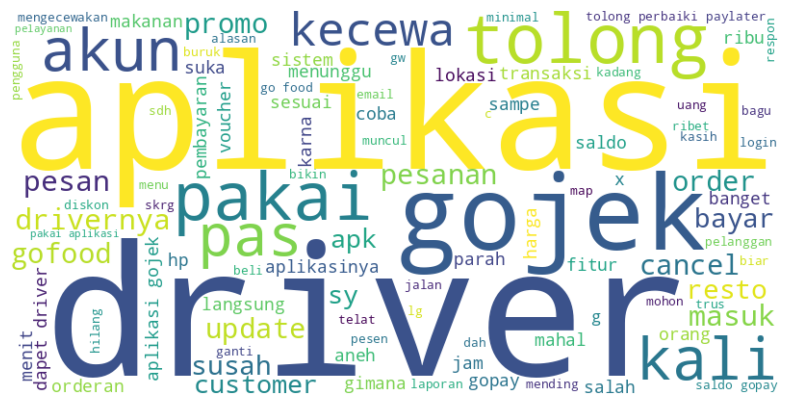

In [87]:
# Tampilkan pada word cloud
text = " ".join(clean_df['text_akhir'].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis', # Warna visual
    max_words=100
).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Sembunyikan sumbu X dan Y
plt.show()

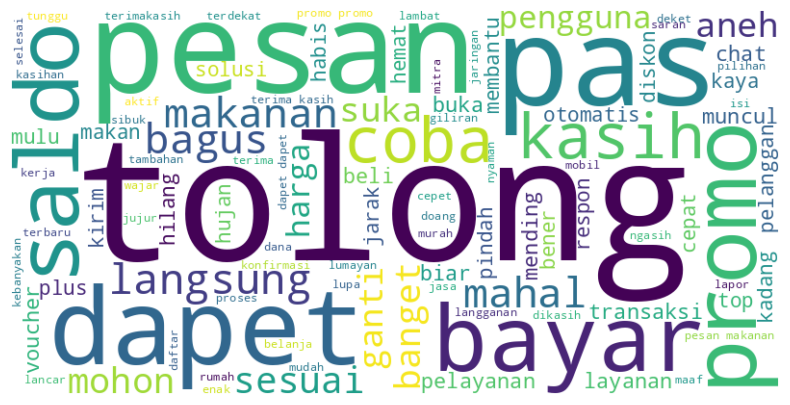

In [88]:
# Tampilkan pada word cloud untuk kata positif
text_flatten_positive = " ".join(flat_positive)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis', # Warna visual
    max_words=100
).generate(text_flatten_positive)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Sembunyikan sumbu X dan Y
plt.show()

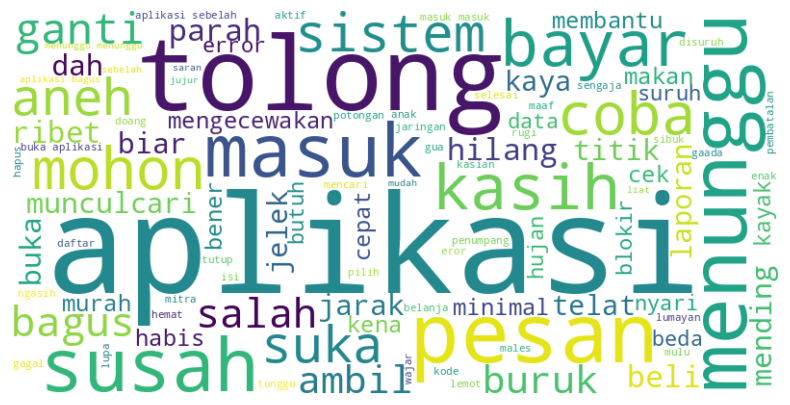

In [89]:
# Tampilkan pada word cloud untuk kata negatif
text_flatten_negative = " ".join(flat_negative)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis', # Warna visual
    max_words=100
).generate(text_flatten_negative)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Sembunyikan sumbu X dan Y
plt.show()

**Data Splitting - TF-IDF**

In [78]:
# Pisahkan data menjadi fitur (tweet) dan label (sentimen)
X = clean_df['text_akhir']
y = clean_df['polarity']

# Ekstraksi fitur dengan TF-IDF
tfidf = TfidfVectorizer(
    max_features=1000,
    min_df=5, # Remove kata yang muncul < 5 kali
    max_df=0.9, # Mengabaikan kata yang umum (90% ada di result)
    ngram_range=(1, 2),   # Gunakan Unigram & Bigram (menangkap kata seperti "tidak enak")
)
X_tfidf = tfidf.fit_transform(X)

# Konversi hasil ekstraksi fitur menjadi dataframe
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

# Bagi data menjadi data latih dan data uji
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

**Data Splitting - Word2Vec**

In [72]:
# Word2Vec butuh input berupa list dari kata-kata (tokenized)
# Kita pecah setiap kalimat di clean_df['text_akhir'] menjadi list kata
sentences = [str(text).split() for text in clean_df['text_akhir']]

# Latih model Word2Vec
w2v_model = Word2Vec(sentences, vector_size=1000, window=5, min_count=1, workers=4)

def get_sentence_vector(sentence, model):
    words = str(sentence).split()
    # Ambil vektor untuk setiap kata jika kata tersebut ada dalam kamus Word2Vec
    word_vectors = [model.wv[word] for word in words if word in model.wv]

    if len(word_vectors) > 0:
        return np.mean(word_vectors, axis=0) # Rata-rata vektor
    else:
        return np.zeros(model.vector_size) # Jika tidak ada kata yang dikenal

# Terapkan fungsi ke semua data
X_w2v = np.array([get_sentence_vector(s, w2v_model) for s in clean_df['text_akhir']])

# Bagi data 80/20 sesuai skema percobaan Anda
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(X_w2v, y, test_size=0.2, random_state=42)

**Modelling - Naive Bayes - TF-IDF**

In [73]:
# Membuat objek model Naive Bayes (Bernoulli Naive Bayes)
naive_bayes = BernoulliNB()

# Melatih model Naive Bayes pada data pelatihan
naive_bayes.fit(X_train_tfidf.toarray(), y_train_tfidf)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_nb = naive_bayes.predict(X_train_tfidf.toarray())
y_pred_test_nb = naive_bayes.predict(X_test_tfidf.toarray())

# Evaluasi akurasi model Naive Bayes
accuracy_train_nb = accuracy_score(y_pred_train_nb, y_train_tfidf)
accuracy_test_nb = accuracy_score(y_pred_test_nb, y_test_tfidf)

# Menampilkan akurasi
print('Naive Bayes + TF-IDF - accuracy_train:', accuracy_train_nb)
print('Naive Bayes + TF-IDF - accuracy_test:', accuracy_test_nb)

Naive Bayes + TF-IDF - accuracy_train: 0.8158887571413173
Naive Bayes + TF-IDF - accuracy_test: 0.7577586206896552


**Modelling - Random Forest - TF-IDF**

In [82]:
# Membuat objek model Random Forest
rf_tfidf = RandomForestClassifier(
    n_estimators=200,
    max_depth=30,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced'
)

# Melatih model Random Forest pada data pelatihan
rf_tfidf.fit(X_train_tfidf.toarray(), y_train_tfidf)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_rf = rf_tfidf.predict(X_train_tfidf.toarray())
y_pred_test_rf = rf_tfidf.predict(X_test_tfidf.toarray())

# Evaluasi akurasi model Random Forest
accuracy_train_rf = accuracy_score(y_pred_train_rf, y_train_tfidf)
accuracy_test_rf = accuracy_score(y_pred_test_rf, y_test_tfidf)

# Menampilkan akurasi
print('Random Forest + TF-IDF - accuracy_train:', accuracy_train_rf)
print('Random Forest + TF-IDF - accuracy_test:', accuracy_test_rf)

Random Forest + TF-IDF - accuracy_train: 0.8336746793144335
Random Forest + TF-IDF - accuracy_test: 0.7051724137931035


**Confusion Matrix - Random Forest - TF-IDF**

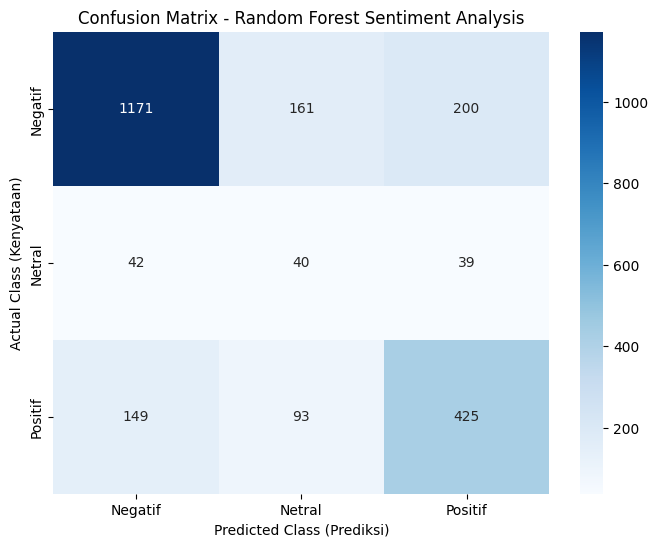


Classification Report:

              precision    recall  f1-score   support

     Negatif       0.86      0.76      0.81      1532
      Netral       0.14      0.33      0.19       121
     Positif       0.64      0.64      0.64       667

    accuracy                           0.71      2320
   macro avg       0.55      0.58      0.55      2320
weighted avg       0.76      0.71      0.73      2320



In [84]:
# 1. Menghitung Confusion Matrix
# Label disesuaikan dengan urutan kategori Anda (Negatif, Netral, Positif)
labels = ['Negatif', 'Netral', 'Positif']
cm = confusion_matrix(y_test_tfidf, y_pred_test_rf)

# 2. Membuat Visualisasi Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.title('Confusion Matrix - Random Forest Sentiment Analysis')
plt.xlabel('Predicted Class (Prediksi)')
plt.ylabel('Actual Class (Kenyataan)')
plt.show()

# 3. Menampilkan Classification Report (Precision, Recall, F1-Score)
print("\nClassification Report:\n")
print(classification_report(y_test_tfidf, y_pred_test_rf, target_names=labels))

**Modelling - Random Forest - W2V**

In [75]:
# Latih Random Forest
rf_w2v = RandomForestClassifier(
    n_estimators=100,   # Jumlah pohon
    max_depth=10,       # Batasi kedalaman pohon agar tidak terlalu hafal data (mencegah overfitting)
    random_state=42
)
rf_w2v.fit(X_train_w2v, y_train_w2v)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_rf_w2v = rf_w2v.predict(X_train_w2v)
y_pred_test_rf_w2v = rf_w2v.predict(X_test_w2v)

# Evaluasi akurasi model Random Forest
accuracy_train_rf_w2v = accuracy_score(y_pred_train_rf_w2v, y_train_w2v)
accuracy_test_rf_w2v = accuracy_score(y_pred_test_rf_w2v, y_test_w2v)

# Menampilkan akurasi
print('Random Forest + W2V - accuracy_train:', accuracy_train_rf_w2v)
print('Random Forest + W2V - accuracy_test:', accuracy_test_rf_w2v)

Random Forest + W2V - accuracy_train: 0.8056483777083109
Random Forest + W2V - accuracy_test: 0.7021551724137931


**Modelling - SVM - W2V**

In [51]:
# Gunakan kernel RBF atau Linear
model_svm = SVC(kernel='linear', C=1.0, probability=True)
model_svm.fit(X_train_w2v, y_train_w2v)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_svm = model_svm.predict(X_test_w2v)
y_pred_test_svm = model_svm.predict(X_test_w2v)

accuracy_train_svm = accuracy_score(y_pred_train_svm, y_train_w2v)
accuracy_test_svm = accuracy_score(y_pred_test_svm, y_test_w2v)

print('SVM + W2V - accuracy_train:', accuracy_train_svm)
print('SVM + W2V - accuracy_test:', accuracy_test_svm)

ValueError: Found input variables with inconsistent numbers of samples: [1652, 6604]